<a href="https://colab.research.google.com/github/DeepaJain29/customer-segmentation/blob/main/customer_segmentation_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Customer Segmentation using K-Means Clustering

In [ ]:
! pip install -q kaggle
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"deepajain2926","key":"9ff63878be873ac80ceb5b7350cb8e85"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


### Step 1 – Importing and Understanding the Dataset

We begin by loading the *Mall Customers* dataset that contains demographic and spending information.
This dataset will help us segment customers based on similar behavioral patterns.


In [ ]:
!kaggle datasets download -d vjchoudhary7/customer-segmentation-tutorial-in-python


Dataset URL: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python
License(s): other
customer-segmentation-tutorial-in-python.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
# Step 3: Unzip dataset
!unzip -o customer-segmentation-tutorial-in-python.zip -d .

# Step 4: Verify the dataset
import pandas as pd
data = pd.read_csv("Mall_Customers.csv")
print("✅ Dataset loaded successfully! Shape:", data.shape)
data.head()

Archive:  customer-segmentation-tutorial-in-python.zip
  inflating: ./Mall_Customers.csv    
✅ Dataset loaded successfully! Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score


### Step 2 – Exploratory Data Analysis (EDA)

We perform EDA to visualize data distributions and relationships among features.

Key goals:
- Check distributions of Age, Annual Income, and Spending Score.
- Identify correlations or separations between variables.


In [ ]:
print(data.info())
print(data.describe())
print(data.isnull().sum)
print(data.duplicated().sum)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000    

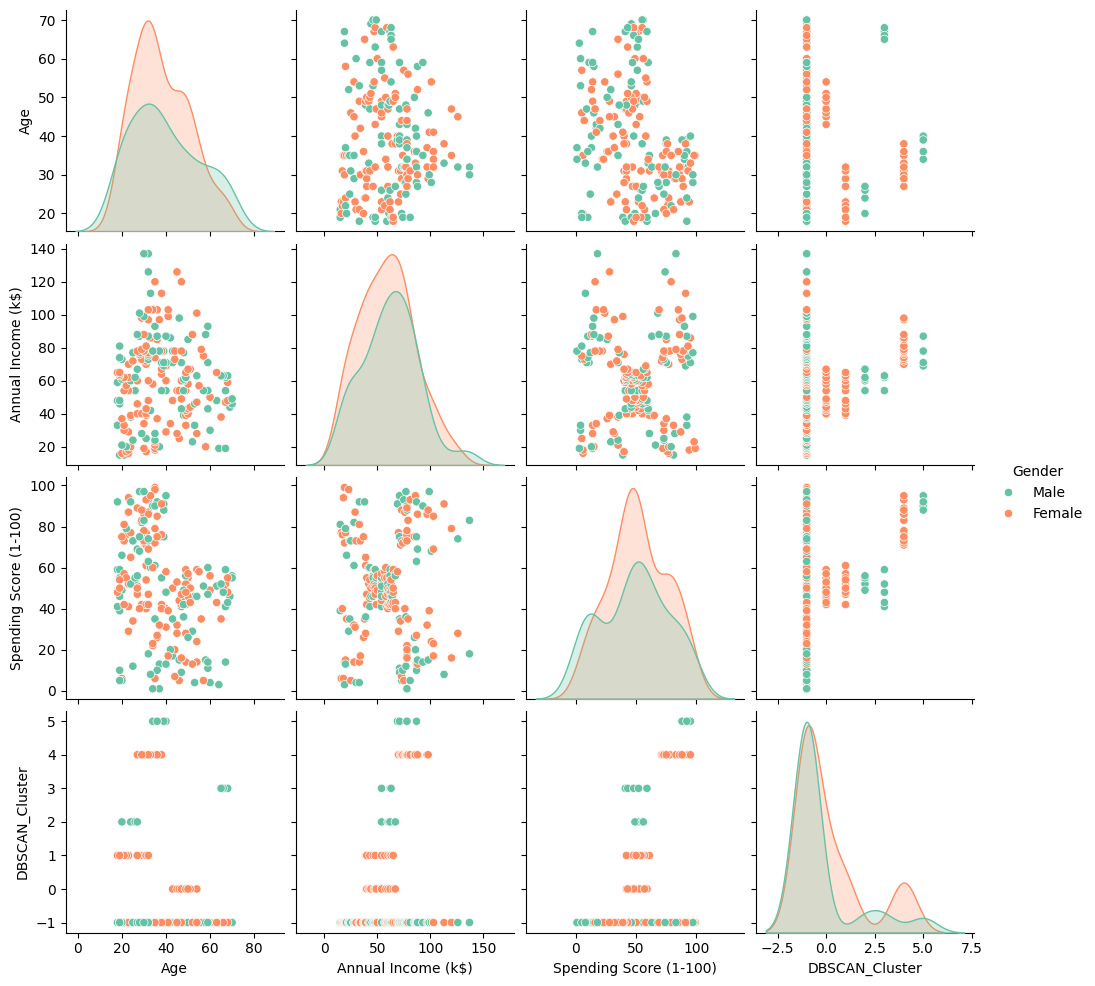

In [ ]:
num_cols = data.select_dtypes(include=['number']).columns.tolist()

sns.pairplot(data, hue='Gender', vars=num_cols, palette='Set2')
plt.show()

### Step 3 – Feature Selection

We select the numerical columns most relevant for clustering:
['Age', 'Annual Income (k$)', 'Spending Score (1-100)'].

Gender is one-hot encoded (Gender_Male) to convert it into numeric form for K-Means.


In [ ]:
print(data['Gender'].value_counts())
data = data.drop(columns=['CustomerID'], axis=0)
data_encoded = pd.get_dummies(data, columns=['Gender'], drop_first=True, dtype=int)
print(data_encoded.head())

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_encoded)


Gender
Female    112
Male       88
Name: count, dtype: int64
   Age  Annual Income (k$)  Spending Score (1-100)  Gender_Male
0   19                  15                      39            1
1   21                  15                      81            1
2   20                  16                       6            0
3   23                  16                      77            0
4   31                  17                      40            0


Each diagonal shows the distribution of a single feature (like Age or Income).  
Off-diagonal scatter plots show relationships between features, colored by cluster labels.  
Clusters forming separate clouds indicate that K-Means found distinct customer groups.


In [ ]:
print(X_scaled)

[[-1.42456879 -1.73899919 -0.43480148  1.12815215]
 [-1.28103541 -1.73899919  1.19570407  1.12815215]
 [-1.3528021  -1.70082976 -1.71591298 -0.88640526]
 [-1.13750203 -1.70082976  1.04041783 -0.88640526]
 [-0.56336851 -1.66266033 -0.39597992 -0.88640526]
 [-1.20926872 -1.66266033  1.00159627 -0.88640526]
 [-0.27630176 -1.62449091 -1.71591298 -0.88640526]
 [-1.13750203 -1.62449091  1.70038436 -0.88640526]
 [ 1.80493225 -1.58632148 -1.83237767  1.12815215]
 [-0.6351352  -1.58632148  0.84631002 -0.88640526]
 [ 2.02023231 -1.58632148 -1.4053405   1.12815215]
 [-0.27630176 -1.58632148  1.89449216 -0.88640526]
 [ 1.37433211 -1.54815205 -1.36651894 -0.88640526]
 [-1.06573534 -1.54815205  1.04041783 -0.88640526]
 [-0.13276838 -1.54815205 -1.44416206  1.12815215]
 [-1.20926872 -1.54815205  1.11806095  1.12815215]
 [-0.27630176 -1.50998262 -0.59008772 -0.88640526]
 [-1.3528021  -1.50998262  0.61338066  1.12815215]
 [ 0.94373197 -1.43364376 -0.82301709  1.12815215]
 [-0.27630176 -1.43364376  1.85

### Step 4 – Finding the Optimal Number of Clusters

We apply the Elbow Method:  
Plot the Within-Cluster Sum of Squares (WCSS) against different k values (number of clusters).

The “elbow point” (where the curve bends) suggests the optimal k.


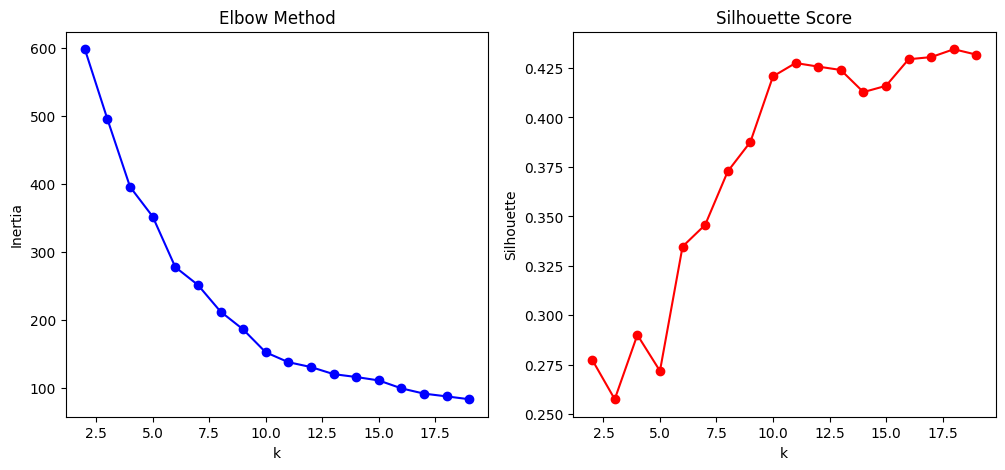

In [ ]:
inertia = []
silhouette = []
K = range(2, 20)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, kmeans.labels_))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(K, inertia, 'bo-')
plt.title('Elbow Method')
plt.xlabel('k'); plt.ylabel('Inertia')

plt.subplot(1,2,2)
plt.plot(K, silhouette, 'ro-')
plt.title('Silhouette Score')
plt.xlabel('k'); plt.ylabel('Silhouette')
plt.show()


The elbow point indicates where adding more clusters doesn’t significantly reduce WCSS,
meaning further segmentation wouldn’t improve performance much.


### Step 5 – Applying K-Means Clustering

Using the chosen k value, we fit the K-Means algorithm.  
Each customer is now assigned to a cluster, stored in a new column called 'KMeans_Cluster'.


In [ ]:
kmeans = KMeans(n_clusters=6, random_state=42)
kmeans.fit(X_scaled)
data_encoded['KMeans_Cluster'] = kmeans.labels_


In [ ]:
best_k = silhouette.index(max(silhouette)) + 2
print("Best k based on Silhouette:", best_k)


Best k based on Silhouette: 18


In [ ]:
# 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender'/
data_encoded.select_dtypes(include=['number'])

,Age,Annual Income (k$),Spending Score (1-100),Gender_Male,KMeans_Cluster
0,19,15,39,1,2
1,21,15,81,1,2
2,20,16,6,0,4
3,23,16,77,0,4
4,31,17,40,0,4
...,...,...,...,...,...
195,35,120,79,0,3
196,45,126,28,0,3
197,32,126,74,1,3
198,32,137,18,1,1


In [ ]:
data_encoded.columns

Index(['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Male',
       'KMeans_Cluster'],
      dtype='object')

### Visualization of Clusters

We plot a 2D scatter plot of Annual Income vs. Spending Score, color-coded by cluster.
This shows how well-separated the clusters are in two key dimensions.


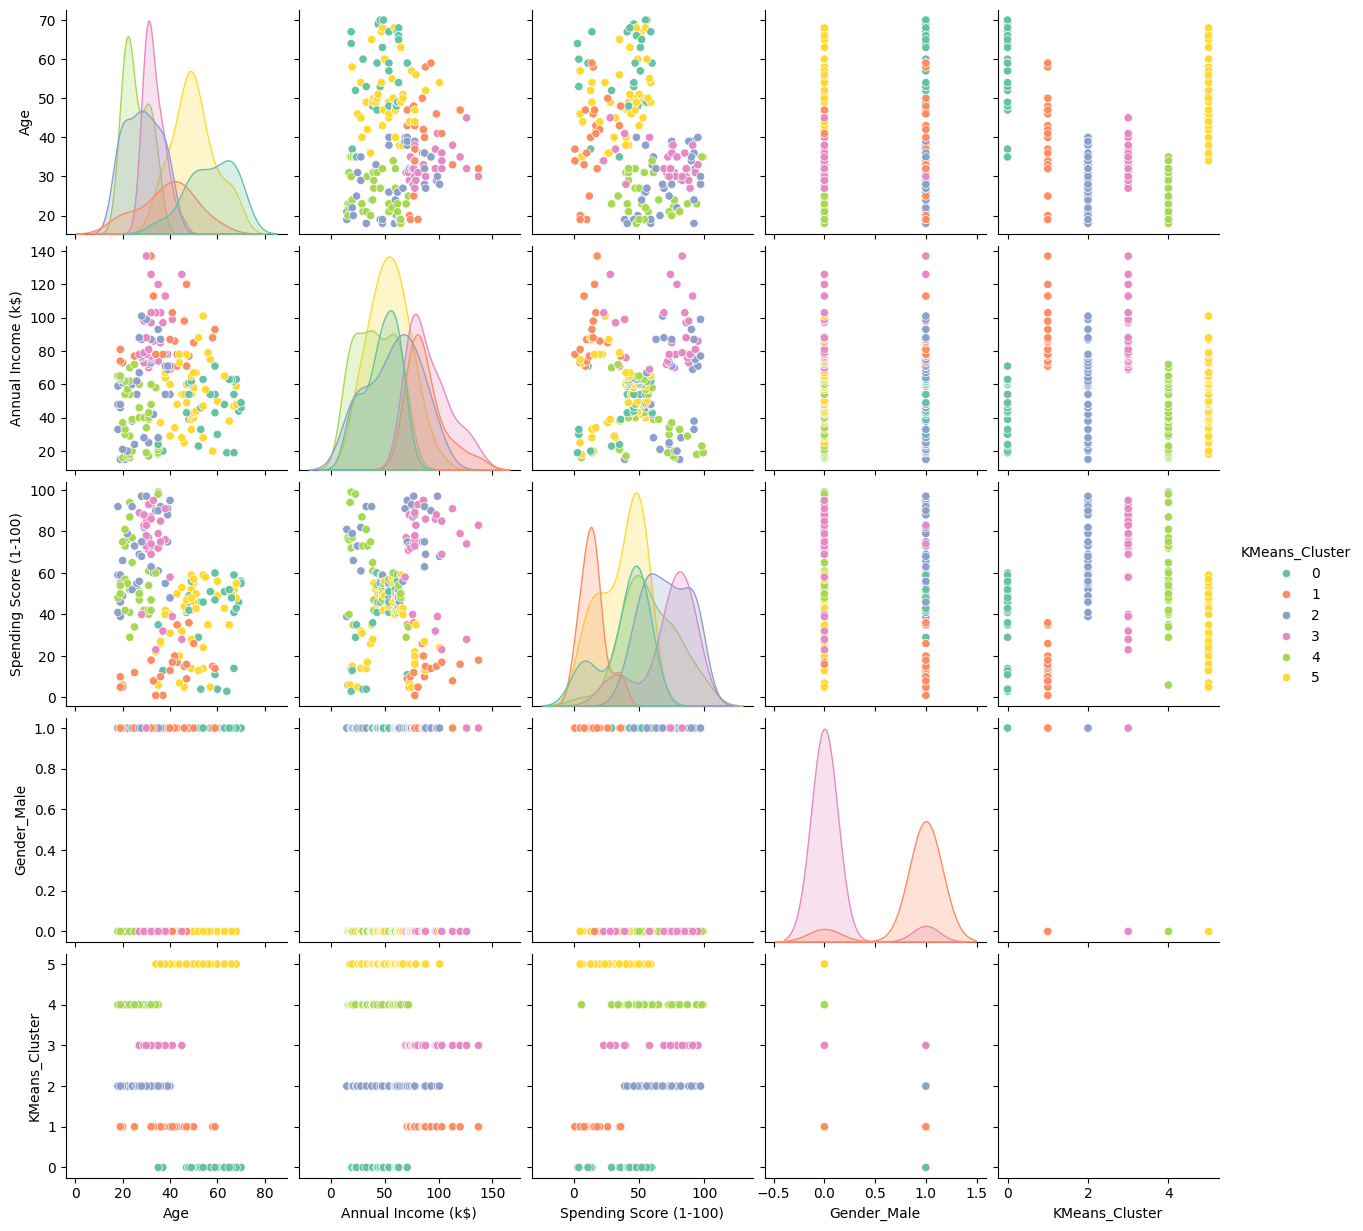

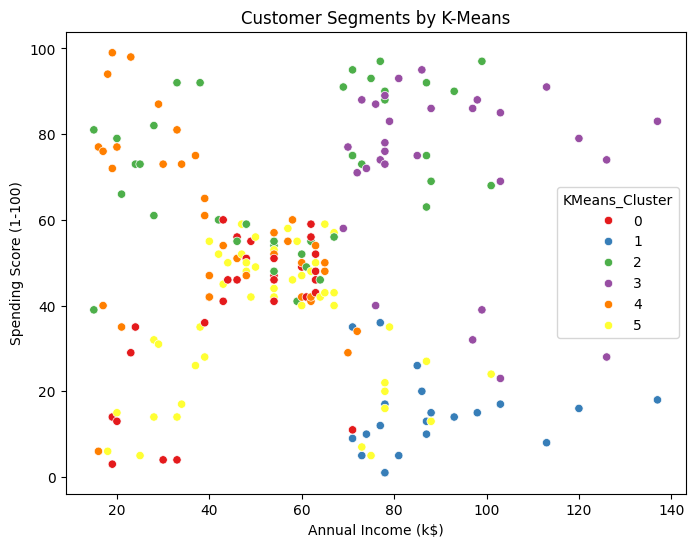

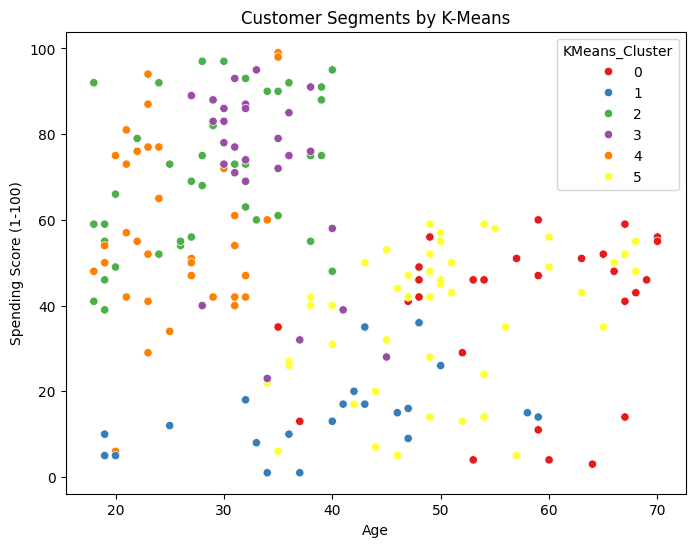

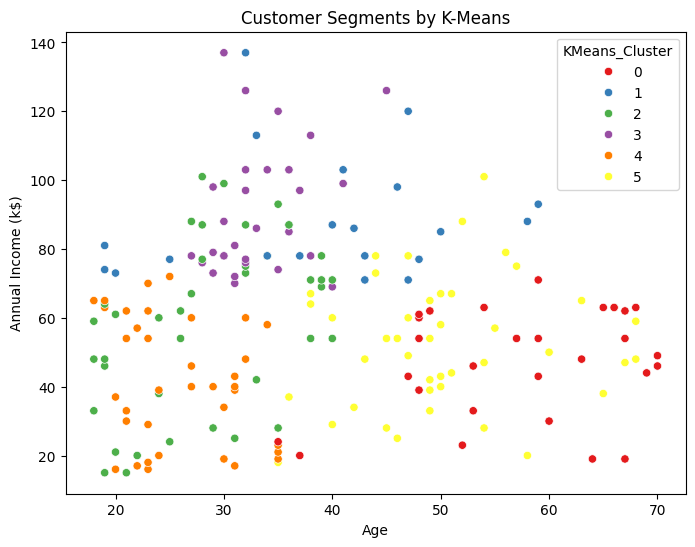

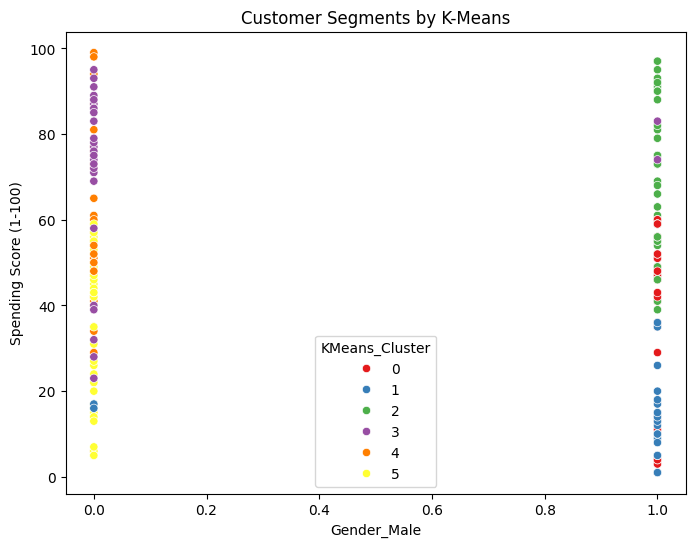

In [ ]:
num_cols = data_encoded.select_dtypes(include=['number']).columns.tolist()

sns.pairplot(data_encoded, hue='KMeans_Cluster', vars=num_cols, palette='Set2')
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='KMeans_Cluster', data=data_encoded, palette='Set1')
plt.title('Customer Segments by K-Means')
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(x='Age', y='Spending Score (1-100)', hue='KMeans_Cluster', data=data_encoded, palette='Set1')
plt.title('Customer Segments by K-Means')
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(x='Age', y='Annual Income (k$)', hue='KMeans_Cluster', data=data_encoded, palette='Set1')
plt.title('Customer Segments by K-Means')
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(x='Gender_Male', y='Spending Score (1-100)', hue='KMeans_Cluster', data=data_encoded, palette='Set1')
plt.title('Customer Segments by K-Means')
plt.show()


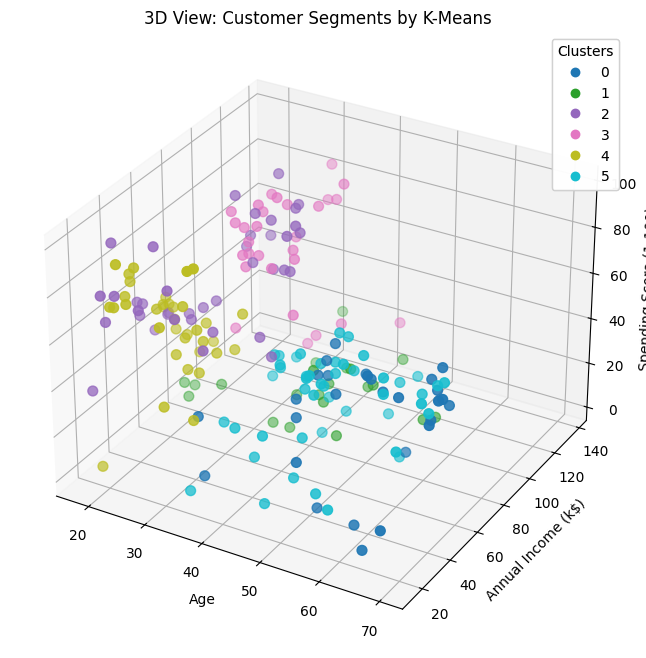

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot for the clusters
scatter = ax.scatter(
    data_encoded['Age'],
    data_encoded['Annual Income (k$)'],
    data_encoded['Spending Score (1-100)'],
    c=data_encoded['KMeans_Cluster'],
    cmap='tab10',
    s=50
)

# Axis labels
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
ax.set_title('3D View: Customer Segments by K-Means')

# Legend
legend = ax.legend(*scatter.legend_elements(), title="Clusters", loc="best")
ax.add_artist(legend)

plt.show()


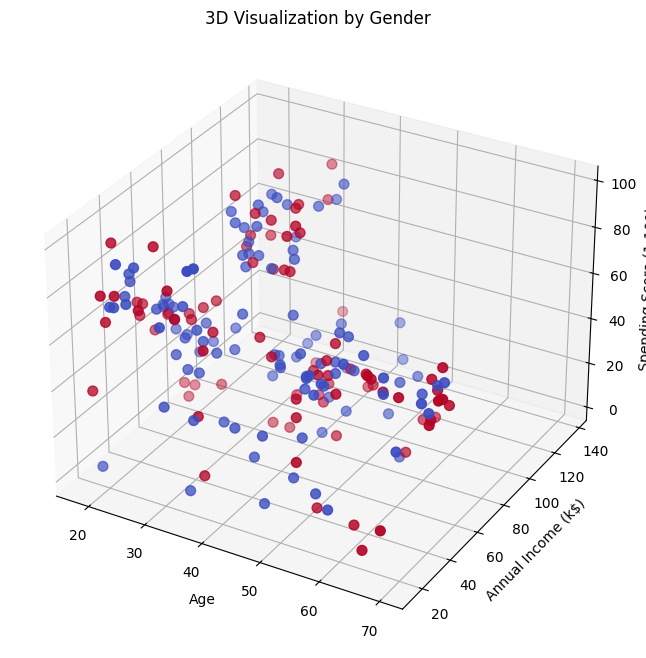

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    data_encoded['Age'],
    data_encoded['Annual Income (k$)'],
    data_encoded['Spending Score (1-100)'],
    c=data_encoded['Gender_Male'],
    cmap='coolwarm',
    s=50
)

ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
ax.set_title('3D Visualization by Gender')
plt.show()


In [ ]:
!pip install plotly
import plotly.express as px

fig = px.scatter_3d(
    data_encoded,
    x='Age',
    y='Annual Income (k$)',
    z='Spending Score (1-100)',
    color='KMeans_Cluster',
    symbol='Gender_Male',
    title='Interactive 3D K-Means Clusters'
)
fig.show()


In [ ]:
from sklearn.metrics import davies_bouldin_score
print("Davies-Bouldin Index:", davies_bouldin_score(X_scaled, kmeans.labels_))


Davies-Bouldin Index: 1.0139617115807866


In [ ]:
from sklearn.metrics import calinski_harabasz_score
print("Calinski-Harabasz Index:", calinski_harabasz_score(X_scaled, kmeans.labels_))


Calinski-Harabasz Index: 73.10031750195824


In [ ]:
data_encoded.groupby('KMeans_Cluster').mean()


,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
KMeans_Cluster,,,,
0,57.214286,46.785714,38.714286,1.000000
1,39.000000,88.333333,14.428571,0.904762
2,28.410256,58.230769,70.717949,1.000000
3,33.206897,91.034483,72.137931,0.068966
4,25.888889,41.277778,57.944444,0.000000
5,49.914894,54.255319,36.531915,0.000000


## Apply DBSCAN

In [ ]:
from sklearn.cluster import DBSCAN

for eps in [0.2, 0.3, 0.4, 0.5, 0.6]:
    db = DBSCAN(eps=eps, min_samples=5)
    db.fit(X_scaled)
    labels = db.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"eps={eps} → clusters={n_clusters}, outliers={(labels == -1).sum()}")


eps=0.2 → clusters=0, outliers=200
eps=0.3 → clusters=1, outliers=194
eps=0.4 → clusters=4, outliers=165
eps=0.5 → clusters=9, outliers=105
eps=0.6 → clusters=9, outliers=62


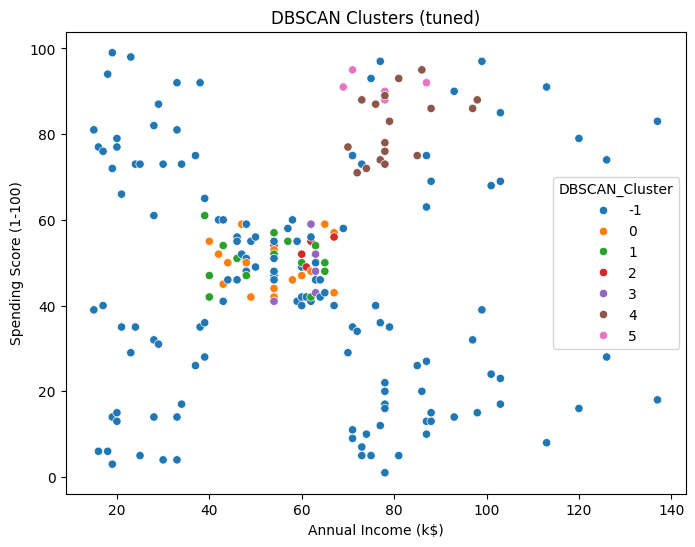

In [ ]:
dbscan = DBSCAN(eps=0.45, min_samples=5)
dbscan.fit(X_scaled)
data['DBSCAN_Cluster'] = dbscan.labels_

# Visualize
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='DBSCAN_Cluster',
    data=data,
    palette='tab10'
)
plt.title('DBSCAN Clusters (tuned)')
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

labels = data['DBSCAN_Cluster']
unique_clusters = len(set(labels)) - (1 if -1 in labels else 0)

if unique_clusters >= 2:
    mask = labels != -1
    print("DBSCAN Silhouette Score:", silhouette_score(X_scaled[mask], labels[mask]))
    print("DBSCAN Davies-Bouldin Index:", davies_bouldin_score(X_scaled[mask], labels[mask]))
else:
    print("⚠️ DBSCAN found only one cluster or all noise — try adjusting eps/min_samples.")


DBSCAN Silhouette Score: 0.6583868108911944
DBSCAN Davies-Bouldin Index: 0.44710439223041504
